# 🟡 Lesson 07 — Shapely

**Level: Intermediate** · The geometry engine under GeoPandas — points, lines, polygons, buffers, intersections.

*Part of the companion package for [python_for_geologists](https://github.com/kevinalexandr19/python_for_geologists) by Kevin Alexander Gomez.*

In [1]:
from shapely.geometry import Point, LineString, Polygon
from shapely import __version__
print("shapely", __version__)

shapely 2.1.2


## 1. The three basic geometries
Coordinates below are UTM metres, so lengths/areas come out in m/m².

In [2]:
collar   = Point(500_000, 8_600_000)                       # a drillhole collar
traverse = LineString([(500_000, 8_600_000), (500_800, 8_600_600), (501_500, 8_600_500)])
claim    = Polygon([(499_500, 8_599_500), (501_500, 8_599_500),
                    (501_500, 8_601_000), (499_500, 8_601_000)])

print("traverse length:", round(traverse.length), "m")
print("claim area     :", claim.area / 1e6, "km2")
print("claim centroid :", claim.centroid)

traverse length: 1707 m
claim area     : 3.0 km2
claim centroid : POINT (500500 8600250)


## 2. Spatial predicates — is the collar inside the claim?

In [3]:
print("collar within claim  :", collar.within(claim))
print("traverse crosses edge:", traverse.crosses(claim.boundary))
print("distance collar->edge:", round(collar.distance(claim.boundary)), "m")

collar within claim  : True
traverse crosses edge: False
distance collar->edge: 500 m


## 3. Buffer — a 250 m exclusion zone around the collar

In [4]:
zone = collar.buffer(250)
print("zone area:", round(zone.area), "m2 (pi*r2 =", round(3.14159 * 250**2), ")")
print("zone fully inside claim:", zone.within(claim))

zone area: 196034 m2 (pi*r2 = 196349 )
zone fully inside claim: True


## 4. Set operations — intersection, union, difference

In [5]:
alteration = Point(500_600, 8_600_300).buffer(700)      # mapped alteration halo

overlap = claim.intersection(alteration)
outside = alteration.difference(claim)
print("alteration inside claim : %.2f km2" % (overlap.area / 1e6))
print("alteration outside claim: %.2f km2" % (outside.area / 1e6))

alteration inside claim : 1.54 km2
alteration outside claim: 0.00 km2


## 5. Sampling along a line — stations every 200 m

In [6]:
stations = [traverse.interpolate(d) for d in range(0, int(traverse.length) + 1, 200)]
for i, s in enumerate(stations):
    print(f"station {i}: ({s.x:.0f}, {s.y:.0f})")

station 0: (500000, 8600000)
station 1: (500160, 8600120)
station 2: (500320, 8600240)
station 3: (500480, 8600360)
station 4: (500640, 8600480)
station 5: (500800, 8600600)
station 6: (500998, 8600572)
station 7: (501196, 8600543)
station 8: (501394, 8600515)


## 6. Quick visual (Shapely plays nicely with Matplotlib)

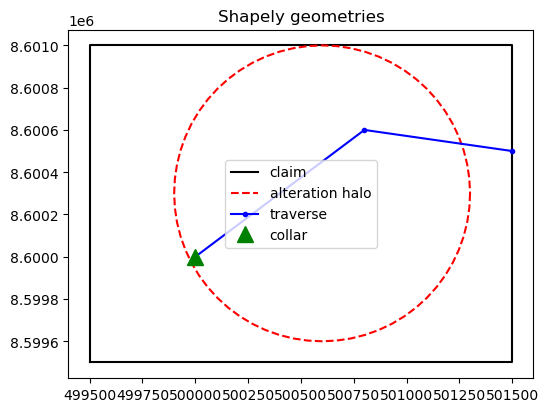

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(*claim.exterior.xy, "k-", label="claim")
ax.plot(*alteration.exterior.xy, "r--", label="alteration halo")
ax.plot(*traverse.xy, "b.-", label="traverse")
ax.plot(collar.x, collar.y, "g^", ms=12, label="collar")
ax.legend(); ax.set_aspect("equal"); ax.set_title("Shapely geometries")
plt.show()

### ✏️ Try it
1. Create a second claim polygon that partially overlaps the first and compute the shared area.
2. Densify the traverse to stations every 50 m and count how many fall inside the alteration halo.

📚 Docs: https://shapely.readthedocs.io/